# Processamento de Linguagem Natural

In [2]:
from pathlib import Path


from dotenv import load_dotenv

import pandas as pd
import seaborn as sb

import nltk
from nltk.corpus import stopwords
from gensim import corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models.ldamodel import LdaModel

from nltk.stem import PorterStemmer, SnowballStemmer

In [3]:
DATASET_DIR = 'dataset'

ROOT_DIR = Path().resolve().__str__()
DATASET_PATH = Path(ROOT_DIR).joinpath(DATASET_DIR)

load_dotenv(ROOT_DIR + 'secrets.env')

False

In [22]:
!kaggle auth login --quiet

usage: kaggle [-h] [-v] [-W]
              {competitions,c,datasets,d,kernels,k,models,m,files,f,forums,fo,benchmarks,b,config,auth}
              ...
kaggle: error: unrecognized arguments: --quiet


In [5]:
import kaggle

kaggle.api.authenticate()
Path.mkdir(Path(DATASET_PATH), parents=True, exist_ok=True)
kaggle.api.dataset_download_files('olistbr/brazilian-ecommerce', path=DATASET_PATH, unzip=True, quiet=False)

print("Path to dataset files: ", DATASET_PATH)

Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce


100%|██████████| 42.6M/42.6M [00:02<00:00, 16.1MB/s]



Path to dataset files:  /home/renata/DataspellProjects/Infnet-MIT-IA-PLN-PD_26E2_/dataset


## Normalização

In [6]:
reviews = pd.read_csv(DATASET_PATH.joinpath('olist_order_reviews_dataset.csv'), encoding='utf-8')
reviews.dropna(axis=0, subset=['review_comment_message'], inplace=True)
reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47
12,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4,NaN,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",2018-02-16 00:00:00,2018-02-20 10:52:22
15,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5,Super recomendo,"Vendedor confiável, produto ok e entrega antes...",2018-05-23 00:00:00,2018-05-24 03:00:01
...,...,...,...,...,...,...,...
99205,98fffa80dc9acbde7388bef1600f3b15,d398e9c82363c12527f71801bf0e6100,4,NaN,para este produto recebi de acordo com a compr...,2017-11-29 00:00:00,2017-11-30 15:52:51
99208,df5fae90e85354241d5d64a8955b2b09,509b86c65fe4e2ad5b96408cfef9755e,5,NaN,Entregou dentro do prazo. O produto chegou em ...,2018-02-07 00:00:00,2018-02-19 19:47:23
99215,a709d176f59bc3af77f4149c96bae357,d5cb12269711bd1eaf7eed8fd32a7c95,3,NaN,"O produto não foi enviado com NF, não existe v...",2018-05-19 00:00:00,2018-05-20 21:51:06
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43


In [7]:
import numpy as np

nltk.download('stopwords')

stop_words = stopwords.words('portuguese')
stop_words.extend(['nan', 'nao', 'sao', 'junto'])

[nltk_data] Downloading package stopwords to /home/renata/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
def clean_text_as_list(text):
    tokens = simple_preprocess(str(text), deacc=True, min_len=3)
    return [token for token in tokens if token not in stop_words]

def clean_text_as_str(text):
    tokens = simple_preprocess(str(text), deacc=True, min_len=3)
    return ' '.join((token for token in tokens if token not in stop_words))

Aplica o mesmo preprocessamento, porém o retorno é diferente para uso distintos (_list_ e _string_).

In [9]:
cols = ['review_comment_title', 'review_comment_message']
reviews['tokens'] = (reviews[cols].astype(str)
                     .apply(lambda x:
                                                 ' '.join([str(x['review_comment_title']), str(x['review_comment_message'] if str(x['review_comment_title']) is not None else str(x['review_comment_message']))]), axis=1)
                     .apply(clean_text_as_list))

In [10]:
reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,tokens
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,"[recebi, bem, antes, prazo, estipulado]"
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53,"[parabens, lojas, lannister, adorei, comprar, ..."
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47,"[recomendo, aparelho, eficiente, site, marca, ..."
12,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4,NaN,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",2018-02-16 00:00:00,2018-02-20 10:52:22,"[pouco, travando, valor, boa]"
15,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5,Super recomendo,"Vendedor confiável, produto ok e entrega antes...",2018-05-23 00:00:00,2018-05-24 03:00:01,"[super, recomendo, vendedor, confiavel, produt..."
...,...,...,...,...,...,...,...,...
99205,98fffa80dc9acbde7388bef1600f3b15,d398e9c82363c12527f71801bf0e6100,4,NaN,para este produto recebi de acordo com a compr...,2017-11-29 00:00:00,2017-11-30 15:52:51,"[produto, recebi, acordo, compra, realizada]"
99208,df5fae90e85354241d5d64a8955b2b09,509b86c65fe4e2ad5b96408cfef9755e,5,NaN,Entregou dentro do prazo. O produto chegou em ...,2018-02-07 00:00:00,2018-02-19 19:47:23,"[entregou, dentro, prazo, produto, chegou, con..."
99215,a709d176f59bc3af77f4149c96bae357,d5cb12269711bd1eaf7eed8fd32a7c95,3,NaN,"O produto não foi enviado com NF, não existe v...",2018-05-19 00:00:00,2018-05-20 21:51:06,"[produto, enviado, existe, venda, certeza, fic..."
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43,"[excelente, mochila, entrega, super, rapida, s..."


<Axes: >

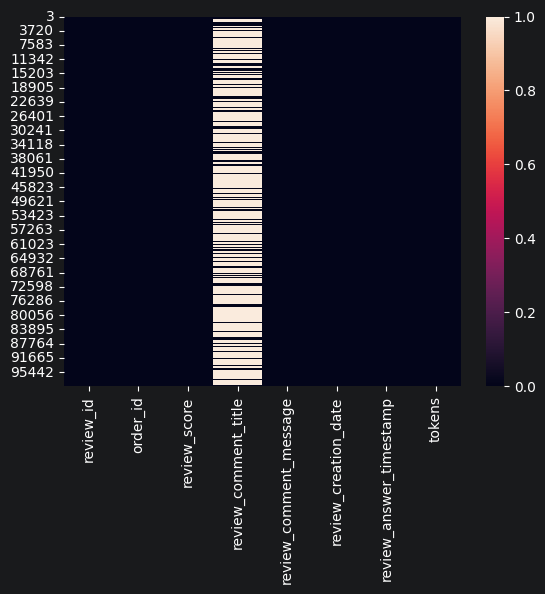

In [11]:
sb.heatmap(reviews.isna())

## Stemming / Snowball

In [12]:
!python -m spacy download pt_core_news_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 6.1 MB/s  0:00:06m0:00:0100:01m
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_md')


In [13]:
from collections import Counter
import spacy
snowball_pt = SnowballStemmer(language="portuguese")
nlp_pt = spacy.load("pt_core_news_md")
tokens_rad = []
for tokens in reviews['tokens']:
    for token in list(tokens):
        token = snowball_pt.stem(token)
        tokens_rad.append(token)

for tuple_tokens in Counter(tokens_rad).most_common(10):
    print(tuple_tokens)

('produt', 20919)
('entreg', 12456)
('praz', 8663)
('compr', 7499)
('receb', 6805)
('cheg', 6607)
('recom', 6067)
('antes', 5680)
('bom', 5661)
('otim', 4857)


## Lematização

In [20]:
docs = (reviews[cols].astype(str)
                     .apply(lambda x:
                                ' '.join([str(x['review_comment_title']), str(x['review_comment_message'] if str(x['review_comment_title']) != 'nan' else str(x['review_comment_message']))]), axis=1
                            )
                    .apply(lambda x:
                                  ' '.join([x])
                           )
                    .apply(clean_text_as_str)
       )

In [21]:
tokens_rad.clear()

for doc in docs:
    lemanizer = nlp_pt(doc)
    for lem in lemanizer:
        tokens_rad.append(lem.lemma_)

for tuple_tokens in Counter(tokens_rad).most_common(10):
    print(tuple_tokens)

('produto', 20897)
('entregar', 9815)
('prazo', 8646)
('bom', 7519)
('chegar', 6556)
('antes', 5680)
('recebi', 5016)
('otimo', 4781)
('comprar', 4356)
('vir', 3736)


## Categorias (Analise de Sentimento)

- 1 = Péssimo
- 2 = Ruim
- 3 = Regular
- 4 = Bom
- 5 = Excelente

In [15]:
# categories = dict({1: ['Péssimo'], 2: ['Ruim'], 3: ['Regular'], 4: ['Bom'], 5: ['Excelente']})
categories = dict({1: 'Péssimo', 2: 'Ruim', 3: 'Regular', 4: 'Bom', 5: 'Excelente'})
# categories = dict({'Péssimo': '1', 'Ruim': '2', 'Regular': '3', 'Bom': '4', 'Excelente': '5'})
cat = np.array(categories.values())